In [176]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

import mlflow
import mlflow.sklearn

In [177]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("FINAL")

2025/12/16 00:52:56 INFO mlflow.tracking.fluent: Experiment with name 'FINAL' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:c:/Users/Aghayeva '
 'Nargiz/OneDrive/Desktop/ML_Project/mlruns/360517131725190492'), creation_time=1765831976940, experiment_id='360517131725190492', last_update_time=1765831976940, lifecycle_stage='active', name='FINAL', tags={}>

In [178]:
data = pd.read_parquet("train.parquet")
data.head()

,contest_name,contest_type,contest_start,contest_start_year,index,time_limit,memory_limit,title,description,input_format,output_format,examples,rating,tags
0,Bubble Cup X - Finals [Online Mirror],ICPC,1504432800,2017,A,1.0,256.0,Digits,John gave Jack a very hard problem. He wrote a...,First line contains a positive integer N (1 ≤ ...,"Output exactly three lines, the steps Jack nee...","[{'input': '1\n1', 'output': '1\n1\n1'}\n {'in...",2500.0,['brute force' 'implementation' 'math']
1,Bubble Cup X - Finals [Online Mirror],ICPC,1504432800,2017,B,2.0,256.0,Neural Network country,Due to the recent popularity of the Deep learn...,The first line of input contains N (1 ≤ N ≤ 10...,"Output a single integer, the number of paths D...","[{'input': '2 3 13\n4 6\n2 1\n3 4', 'output': ...",2000.0,['dp' 'matrices']
2,Bubble Cup X - Finals [Online Mirror],ICPC,1504432800,2017,C,0.5,256.0,Property,Bill is a famous mathematician in BubbleLand. ...,The first line contains one integer number n (...,Output contains n distinct integers separated ...,"[{'input': '3\n0 1 2', 'output': '0 2 1'}]",2100.0,['greedy' 'sortings']
3,Bubble Cup X - Finals [Online Mirror],ICPC,1504432800,2017,D,2.0,256.0,Exploration plan,The competitors of Bubble Cup X gathered after...,"The first line contains four integers: V, E, N...",Output a single integer that represents the mi...,[{'input': '6 7 5 4\n5 5 2 2 5\n1 3 3\n1 5 2\n...,2100.0,['binary search' 'flows' 'graph matchings' 'sh...
4,Bubble Cup X - Finals [Online Mirror],ICPC,1504432800,2017,E,1.0,256.0,Casinos and travel,John has just bought a new car and is planning...,"In the first line, a positive integer N (1 ≤ N...","Output one number, the answer to the problem m...","[{'input': '2\n1 2', 'output': '4'}\n {'input'...",2100.0,['dp']


In [179]:
data[["rating", "time_limit", "memory_limit"]].describe()


,rating,time_limit,memory_limit
count,9556.000000,9556.000000,9556.000000
mean,1854.437003,2.092329,294.319799
std,706.332415,1.555807,132.112632
min,800.000000,0.400000,4.000000
25%,1300.000000,1.000000,256.000000
50%,1800.000000,2.000000,256.000000
75%,2400.000000,2.000000,256.000000
max,3500.000000,60.000000,1024.000000


In [180]:
data.isnull().sum().sort_values(ascending=False)

contest_name          0
contest_type          0
contest_start         0
contest_start_year    0
index                 0
time_limit            0
memory_limit          0
title                 0
description           0
input_format          0
output_format         0
examples              0
rating                0
tags                  0
dtype: int64

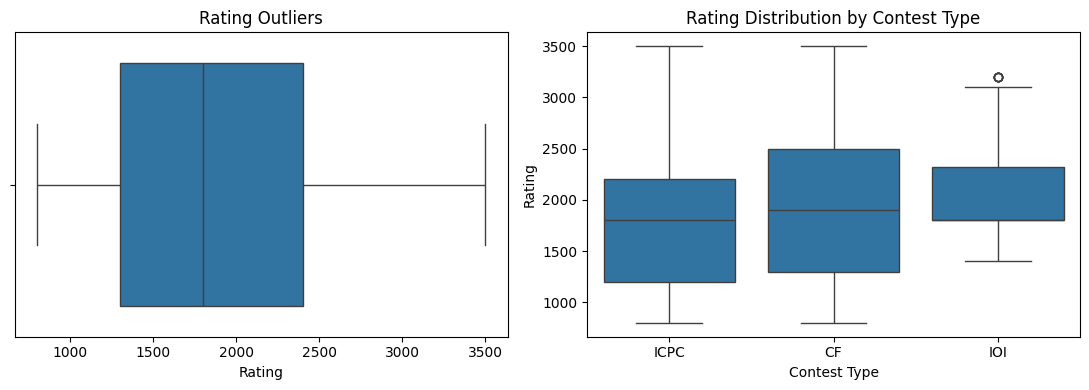

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot 1: Rating outliers
sns.boxplot(x=data["rating"], ax=axes[0])
axes[0].set_title("Rating Outliers")
axes[0].set_xlabel("Rating")

# Boxplot 2: Rating by contest type
sns.boxplot(x="contest_type", y="rating", data=data, ax=axes[1])
axes[1].set_title("Rating Distribution by Contest Type")
axes[1].set_xlabel("Contest Type")
axes[1].set_ylabel("Rating")

plt.tight_layout()
plt.show()


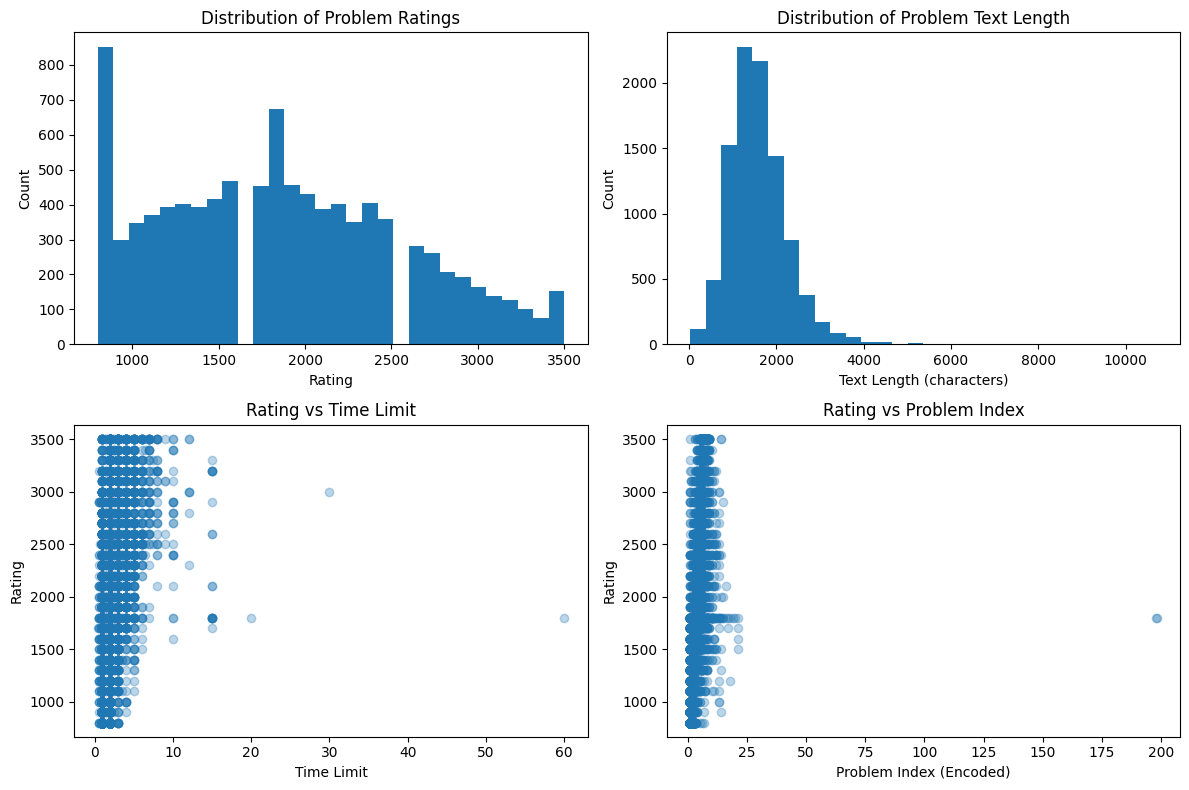

In [182]:
text_cols = ["title", "description", "input_format", "output_format"]
data["text_length"] = data[text_cols].fillna("").agg(
    lambda x: sum(len(str(v)) for v in x), axis=1
)

def encode_index_eda(idx):
    if pd.isna(idx):
        return None
    idx = str(idx).strip()
    m = re.match(r"([A-Za-z]+)(\d*)", idx)
    if not m:
        return None
    letters, nums = m.groups()
    base = 0
    for c in letters.upper():
        base = base * 26 + (ord(c) - ord("A") + 1)
    if nums.isdigit() and nums != "":
        base += int(nums) / 10.0
    return base

data["index_encoded"] = data["index"].apply(encode_index_eda)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))


axes[0, 0].hist(data["rating"], bins=30)
axes[0, 0].set_title("Distribution of Problem Ratings")
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(data["text_length"], bins=30)
axes[0, 1].set_title("Distribution of Problem Text Length")
axes[0, 1].set_xlabel("Text Length (characters)")
axes[0, 1].set_ylabel("Count")

axes[1, 0].scatter(data["time_limit"], data["rating"], alpha=0.3)
axes[1, 0].set_title("Rating vs Time Limit")
axes[1, 0].set_xlabel("Time Limit")
axes[1, 0].set_ylabel("Rating")

axes[1, 1].scatter(data["index_encoded"], data["rating"], alpha=0.3)
axes[1, 1].set_title("Rating vs Problem Index")
axes[1, 1].set_xlabel("Problem Index (Encoded)")
axes[1, 1].set_ylabel("Rating")

plt.tight_layout()
plt.show()

In [183]:
data["desc_len"] = data["description"].str.len()
data["title_len"] = data["title"].str.len()

text_features = [
    "desc_len",
    "title_len",
    "rating"
]

data[text_features].corr(method="spearman")["rating"].sort_values(ascending=False)


rating       1.000000
desc_len     0.231509
title_len    0.046275
Name: rating, dtype: float64

In [184]:
data = pd.get_dummies(data, columns=["contest_type"], prefix="type")

In [185]:
def encode_index(idx):
    if pd.isna(idx):
        return np.nan
    idx = str(idx).strip()
    if not idx:
        return np.nan
    m = re.match(r"([A-Za-z]+)(\d*)", idx)
    if not m:
        return np.nan
    letters, nums = m.groups()
    base = 0
    for c in letters.upper():
        base = base * 26 + (ord(c) - ord("A") + 1)
    if nums.isdigit() and nums != "":
        base += int(nums) / 10.0
    return base

data["index_encoded"] = data["index"].apply(encode_index)


In [186]:
# Drop irrelevant columns
drop_cols = ["contest_name", "tags", "examples"]
data = data.drop(columns=drop_cols)

# Time features
data["contest_start_datetime"] = pd.to_datetime(data["contest_start"], unit="s")
data["contest_month"] = data["contest_start_datetime"].dt.month
data["contest_day_of_week"] = data["contest_start_datetime"].dt.weekday
data["contest_day"] = data["contest_start_datetime"].dt.day
data["contest_age"] = 2025 - data["contest_start_year"]
#data = data.drop(columns=["contest_start_datetime", "contest_start_year", "contest_start"])


print("Preprocessing done. Shape:", data.shape)


Preprocessing done. Shape: (9556, 22)


In [187]:
data.columns

Index(['contest_start', 'contest_start_year', 'index', 'time_limit',
       'memory_limit', 'title', 'description', 'input_format', 'output_format',
       'rating', 'text_length', 'index_encoded', 'desc_len', 'title_len',
       'type_CF', 'type_ICPC', 'type_IOI', 'contest_start_datetime',
       'contest_month', 'contest_day_of_week', 'contest_day', 'contest_age'],
      dtype='object')

In [188]:
features_for_corr = [
    "time_limit",
    "memory_limit",
    "index_encoded",
    "desc_len",
    "title_len",
    "type_CF",
    "type_ICPC",
    "type_IOI",
    "contest_month",
    "contest_day_of_week",
    "contest_day",
    "contest_age",
    "contest_start",
    "contest_start_year",
    "contest_start_datetime",
    "rating"
]

corrs = data[features_for_corr].corr(method="spearman")["rating"]
corrs.sort_values(ascending=False)


rating                    1.000000
index_encoded             0.742429
time_limit                0.455261
memory_limit              0.233562
desc_len                  0.231509
type_CF                   0.097237
contest_day_of_week       0.095143
title_len                 0.046275
contest_age               0.035666
type_IOI                  0.034004
contest_month             0.021641
contest_day              -0.008452
contest_start_datetime   -0.034111
contest_start            -0.034111
contest_start_year       -0.035666
type_ICPC                -0.104659
Name: rating, dtype: float64

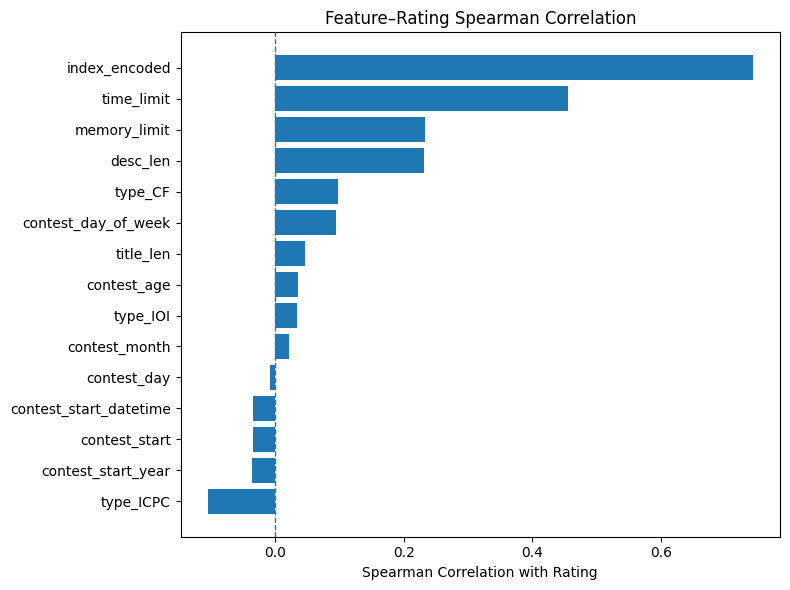

In [189]:
import matplotlib.pyplot as plt

# Compute correlations
corrs = data[features_for_corr].corr(method="spearman")["rating"].drop("rating")
corrs = corrs.sort_values()

plt.figure(figsize=(8, 6))
plt.barh(corrs.index, corrs.values)
plt.xlabel("Spearman Correlation with Rating")
plt.title("Feature–Rating Spearman Correlation")
plt.axvline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


In [190]:
numeric_features = [
    "index_encoded",   # strongest signal
    "time_limit",
    "memory_limit",
    "contest_day_of_week",
    "contest_month"
]

categorical_features = [
    "type_CF",
    "type_ICPC",
    "type_IOI"
]

feature_cols = numeric_features + categorical_features

target_col = "rating"

X = data[feature_cols]
y = data[target_col]

print(X.shape, y.shape)


(9556, 8) (9556,)


In [191]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_fold(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)
    sp = spearmanr(y_true, y_pred).correlation
    return mae, rmse, r2, sp


def run_kfold_model(model, X, y, name):
    with mlflow.start_run(run_name=name):
        for k, v in model.get_params().items():
            mlflow.log_param(k, str(v))

        maes, rmses, r2s, sps = [], [], [], []

        for i, (tr, va) in enumerate(kf.split(X), 1):
            X_tr, X_va = X.iloc[tr], X.iloc[va]
            y_tr, y_va = y.iloc[tr], y.iloc[va]

            model.fit(X_tr, y_tr)
            preds = model.predict(X_va)

            mae = mean_absolute_error(y_va, preds)
            mse = mean_squared_error(y_va, preds)
            rmse = mse ** 0.5
            r2 = r2_score(y_va, preds)
            sp = spearmanr(y_va, preds).correlation

            maes.append(mae)
            rmses.append(rmse)
            r2s.append(r2)
            sps.append(sp)

            print(f"Fold {i} — MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}, Spearman: {sp:.3f}")
            
        mlflow.log_metric("MAE_mean", np.mean(maes))
        mlflow.log_metric("RMSE_mean", np.mean(rmses))
        mlflow.log_metric("R2_mean", np.mean(r2s))
        mlflow.log_metric("Spearman_mean", np.mean(sps))

        mlflow.log_metric("MAE_std", np.std(maes))
        mlflow.log_metric("RMSE_std", np.std(rmses))

        print(f"\n=== {name} ===")
        print(f"MAE: {np.mean(maes):.2f}")
        print(f"RMSE: {np.mean(rmses):.2f}")
        print(f"R²: {np.mean(r2s):.3f}")
        print(f"Spearman: {np.mean(sps):.3f}")

       



In [192]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

run_kfold_model(lr_pipeline, X, y, "Linear Regression (numeric)")


Fold 1 — MAE: 429.48, RMSE: 661.16, R²: 0.120, Spearman: 0.761
Fold 2 — MAE: 463.17, RMSE: 563.63, R²: 0.390, Spearman: 0.683
Fold 3 — MAE: 446.62, RMSE: 549.20, R²: 0.377, Spearman: 0.693
Fold 4 — MAE: 450.23, RMSE: 585.12, R²: 0.293, Spearman: 0.684
Fold 5 — MAE: 439.94, RMSE: 672.63, R²: 0.109, Spearman: 0.736

=== Linear Regression (numeric) ===
MAE: 445.89
RMSE: 606.35
R²: 0.258
Spearman: 0.711


In [193]:
ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
run_kfold_model(ridge_pipeline, X, y, "Ridge Regression (numeric)")

Fold 1 — MAE: 429.49, RMSE: 661.14, R²: 0.120, Spearman: 0.761
Fold 2 — MAE: 463.18, RMSE: 563.64, R²: 0.390, Spearman: 0.683
Fold 3 — MAE: 446.63, RMSE: 549.21, R²: 0.377, Spearman: 0.693
Fold 4 — MAE: 450.23, RMSE: 585.12, R²: 0.293, Spearman: 0.684
Fold 5 — MAE: 439.95, RMSE: 672.60, R²: 0.109, Spearman: 0.736

=== Ridge Regression (numeric) ===
MAE: 445.90
RMSE: 606.34
R²: 0.258
Spearman: 0.711


In [194]:
xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=600,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])
run_kfold_model(xgb_pipeline, X, y, "XGBoost (numeric)")

Fold 1 — MAE: 327.53, RMSE: 417.75, R²: 0.649, Spearman: 0.816
Fold 2 — MAE: 333.33, RMSE: 428.54, R²: 0.648, Spearman: 0.812
Fold 3 — MAE: 312.95, RMSE: 402.46, R²: 0.665, Spearman: 0.823
Fold 4 — MAE: 322.78, RMSE: 409.80, R²: 0.653, Spearman: 0.815
Fold 5 — MAE: 323.07, RMSE: 414.70, R²: 0.661, Spearman: 0.818

=== XGBoost (numeric) ===
MAE: 323.93
RMSE: 414.65
R²: 0.655
Spearman: 0.817


In [195]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", CatBoostRegressor(
        iterations=600,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        verbose=False
    ))
])
run_kfold_model(cat_pipeline, X, y, "CatBoost (numeric)")

Fold 1 — MAE: 301.77, RMSE: 383.40, R²: 0.704, Spearman: 0.844
Fold 2 — MAE: 314.28, RMSE: 398.61, R²: 0.695, Spearman: 0.836
Fold 3 — MAE: 292.73, RMSE: 369.67, R²: 0.718, Spearman: 0.849
Fold 4 — MAE: 307.40, RMSE: 384.63, R²: 0.694, Spearman: 0.834
Fold 5 — MAE: 306.28, RMSE: 385.96, R²: 0.706, Spearman: 0.841

=== CatBoost (numeric) ===
MAE: 304.49
RMSE: 384.45
R²: 0.704
Spearman: 0.841


In [196]:
import pandas as pd
import numpy as np
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from catboost import CatBoostRegressor


test_data = pd.read_parquet("test.parquet")


# Drop irrelevant columns
drop_cols = ["contest_name", "tags", "examples"]
test_data = test_data.drop(columns=[c for c in drop_cols if c in test_data.columns])

# Time features
test_data["contest_start_datetime"] = pd.to_datetime(test_data["contest_start"], unit="s")
test_data["contest_month"] = test_data["contest_start_datetime"].dt.month
test_data["contest_day_of_week"] = test_data["contest_start_datetime"].dt.weekday
test_data["contest_day"] = test_data["contest_start_datetime"].dt.day
test_data["contest_age"] = 2025 - test_data["contest_start_year"]
test_data = test_data.drop(columns=["contest_start_datetime"])

# One-hot encode contest type
test_data = pd.get_dummies(test_data, columns=["contest_type"], prefix="type")

# Ensure same categorical columns as training
for col in ["type_CF", "type_ICPC", "type_IOI"]:
    if col not in test_data.columns:
        test_data[col] = 0

# Encode problem index
def encode_index(idx):
    if pd.isna(idx):
        return np.nan
    idx = str(idx).strip()
    if not idx:
        return np.nan
    m = re.match(r"([A-Za-z]+)(\d*)", idx)
    if not m:
        return np.nan
    letters, nums = m.groups()
    base = 0
    for c in letters.upper():
        base = base * 26 + (ord(c) - ord("A") + 1)
    if nums.isdigit() and nums != "":
        base += int(nums) / 10.0
    return base

test_data["index_encoded"] = test_data["index"].apply(encode_index)


X_test = test_data[feature_cols]
y_test = test_data["rating"]  


cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", CatBoostRegressor(
        iterations=600,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        verbose=False
    ))
])


cat_pipeline.fit(X, y)


test_preds = cat_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, test_preds)
mse = mean_squared_error(y_test, test_preds)
rmse = mse ** 0.5
r2 = r2_score(y_test, test_preds)
sp = spearmanr(y_test, test_preds).correlation

print("=== FINAL TEST RESULTS (LEAKAGE-FREE) ===")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")
print(f"Spearman: {sp:.3f}")


=== FINAL TEST RESULTS (LEAKAGE-FREE) ===
MAE: 341.76
RMSE: 424.71
R²: 0.735
Spearman: 0.887


## Working with both- Numeric and Textual features

In [197]:
import re
import pandas as pd

def clean_text_cp(s):
    if pd.isna(s):
        return ""

    s = str(s).lower()

    # Normalize whitespace
    s = s.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    s = re.sub(r"\s+", " ", s)

    # Replace math symbols with text equivalents
    s = s.replace("≤", " <= ").replace("≥", " >= ")
    s = s.replace("≠", " != ").replace("→", " -> ")

    # Normalize numbers (keep structure, reduce sparsity)
    s = re.sub(r"\b\d+(\.\d+)?\b", " NUM ", s)

    # Remove excessive punctuation (keep operators)
    s = re.sub(r"[^\w\s\+\-\*/<>=]", " ", s)

    # Final cleanup
    s = re.sub(r"\s+", " ", s).strip()

    return s

text_cols = ["title", "description", "input_format", "output_format"]

for col in text_cols:
    data[col + "_clean"] = data[col].apply(clean_text_cp)

data["all_text"] = (
    data["title_clean"] + " " +
    data["description_clean"] + " " +
    data["input_format_clean"] + " " +
    data["output_format_clean"]
)

print("Text ready. Example:\n", data["all_text"].iloc[0][:400])


Text ready. Example:
 digits john gave jack a very hard problem he wrote a very big positive integer a0 on a piece of paper the number is less than NUM in each step jack is allowed to put + signs in between some of the digits maybe none of the current number and calculate the sum of the expression he can perform the same procedure on that sum and so on the resulting sums can be labeled respectively by a1 a2 etc his tas


In [198]:
data.columns

Index(['contest_start', 'contest_start_year', 'index', 'time_limit',
       'memory_limit', 'title', 'description', 'input_format', 'output_format',
       'rating', 'text_length', 'index_encoded', 'desc_len', 'title_len',
       'type_CF', 'type_ICPC', 'type_IOI', 'contest_start_datetime',
       'contest_month', 'contest_day_of_week', 'contest_day', 'contest_age',
       'title_clean', 'description_clean', 'input_format_clean',
       'output_format_clean', 'all_text'],
      dtype='object')

In [199]:
numeric_features = [
    "index_encoded",   # strongest signal
    "time_limit",
    "memory_limit",
    "contest_day_of_week",
    "contest_month",
    "desc_len",
    "title_len",
]

categorical_features = ["type_CF", "type_ICPC", "type_IOI"]
all_numeric_cols = numeric_features + categorical_features

missing = [c for c in ["all_text"] + all_numeric_cols + ["rating"] if c not in data.columns]
print("Missing columns:", missing)

final_test_mask = data["contest_start_year"] >= 2023
train_full = data[~final_test_mask].copy()
test_final  = data[final_test_mask].copy()

X = train_full[["all_text"] + all_numeric_cols]
y = train_full["rating"]

print("Train X shape:", X.shape, "y shape:", y.shape)


Missing columns: []
Train X shape: (8234, 11) y shape: (8234,)


In [200]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

# Numeric pipelines
num_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

num_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocessors
preprocess_text_num_scaled = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf, "all_text"),
        ("num", num_scaled, all_numeric_cols)
    ],
    remainder="drop"
)

preprocess_text_num_unscaled = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf, "all_text"),
        ("num", num_unscaled, all_numeric_cols)
    ],
    remainder="drop"
)

print("Preprocessors ready.")


Preprocessors ready.


In [201]:
from sklearn.svm import LinearSVR
from sklearn.linear_model import Ridge, ElasticNet, ElasticNetCV
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

svr_textnum = Pipeline([
    ("preprocess", preprocess_text_num_scaled),
    ("model", LinearSVR(C=1.0))
])

ridge_textnum = Pipeline([
    ("preprocess", preprocess_text_num_scaled),
    ("model", Ridge(alpha=1.0))
])

lgbm_textnum = Pipeline([
    ("preprocess", preprocess_text_num_unscaled),
    ("model", LGBMRegressor(
        n_estimators=300,          # ← from grid search
        learning_rate=0.05,
        num_leaves=64,
        max_depth=20,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ))
])
elastic_textnum = Pipeline([
    ("preprocess", preprocess_text_num_scaled),
    ("model", ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42
    ))
])

xgb_textnum = Pipeline([
    ("preprocess", preprocess_text_num_unscaled),
    ("model", XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])



print("Text + numeric models are ready.")


Text + numeric models are ready.


In [203]:
import mlflow
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

#mlflow.set_experiment("Text+Numeric_Models_Comparison")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def run_kfold_model(model, X, y, name):
    with mlflow.start_run(run_name=name):

        # log params
        for k, v in model.get_params().items():
            mlflow.log_param(k, str(v))

        maes, rmses, r2s, sps = [], [], [], []

        for i, (tr, va) in enumerate(kf.split(X), 1):
            X_tr, X_va = X.iloc[tr], X.iloc[va]
            y_tr, y_va = y.iloc[tr], y.iloc[va]

            model.fit(X_tr, y_tr)
            preds = model.predict(X_va)

            mae = mean_absolute_error(y_va, preds)
            rmse = np.sqrt(mean_squared_error(y_va, preds))
            r2 = r2_score(y_va, preds)
            sp = spearmanr(y_va, preds).correlation

            maes.append(mae); rmses.append(rmse); r2s.append(r2); sps.append(sp)

            print(f"Fold {i} — MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}, Spearman: {sp:.3f}")
            

        mlflow.log_metric("MAE_mean", float(np.mean(maes)))
        mlflow.log_metric("RMSE_mean", float(np.mean(rmses)))
        mlflow.log_metric("R2_mean", float(np.mean(r2s)))
        mlflow.log_metric("Spearman_mean", float(np.mean(sps)))

        mlflow.log_metric("MAE_std", float(np.std(maes)))
        mlflow.log_metric("RMSE_std", float(np.std(rmses)))

        print(f"\n=== {name} ===")
        print(f"MAE: {np.mean(maes):.2f}")
        print(f"RMSE: {np.mean(rmses):.2f}")
        print(f"R²: {np.mean(r2s):.3f}")
        print(f"Spearman: {np.mean(sps):.3f}\n")

        return {"MAE": maes, "RMSE": rmses, "R2": r2s, "Spearman": sps}


In [204]:
results_svr_textnum = run_kfold_model(svr_textnum, X, y, "LinearSVR (TFIDF + numeric)")

Fold 1 — MAE: 374.67, RMSE: 484.69, R²: 0.524, Spearman: 0.775
Fold 2 — MAE: 368.64, RMSE: 480.87, R²: 0.519, Spearman: 0.779
Fold 3 — MAE: 369.11, RMSE: 469.88, R²: 0.524, Spearman: 0.774
Fold 4 — MAE: 390.28, RMSE: 1066.33, R²: -1.384, Spearman: 0.781
Fold 5 — MAE: 391.75, RMSE: 1075.21, R²: -1.373, Spearman: 0.779

=== LinearSVR (TFIDF + numeric) ===
MAE: 378.89
RMSE: 715.39
R²: -0.238
Spearman: 0.778



In [205]:
results_ridge_textnum = run_kfold_model(ridge_textnum, X, y, "Ridge (TFIDF + numeric)")

Fold 1 — MAE: 388.83, RMSE: 490.40, R²: 0.512, Spearman: 0.735
Fold 2 — MAE: 384.00, RMSE: 476.30, R²: 0.528, Spearman: 0.732
Fold 3 — MAE: 388.44, RMSE: 488.33, R²: 0.485, Spearman: 0.710
Fold 4 — MAE: 397.51, RMSE: 548.74, R²: 0.369, Spearman: 0.714
Fold 5 — MAE: 383.12, RMSE: 532.30, R²: 0.418, Spearman: 0.744

=== Ridge (TFIDF + numeric) ===
MAE: 388.38
RMSE: 507.21
R²: 0.463
Spearman: 0.727



In [206]:
results_elastic_textnum = run_kfold_model(elastic_textnum, X, y, "ElasticNet_text_numeric")

Fold 1 — MAE: 458.28, RMSE: 563.74, R²: 0.356, Spearman: 0.690
Fold 2 — MAE: 451.76, RMSE: 545.93, R²: 0.380, Spearman: 0.706
Fold 3 — MAE: 445.22, RMSE: 544.80, R²: 0.360, Spearman: 0.678
Fold 4 — MAE: 438.80, RMSE: 668.93, R²: 0.062, Spearman: 0.716
Fold 5 — MAE: 436.51, RMSE: 654.39, R²: 0.121, Spearman: 0.739

=== ElasticNet_text_numeric ===
MAE: 446.11
RMSE: 595.56
R²: 0.256
Spearman: 0.706



In [207]:
results_lgbm_textnum  = run_kfold_model(lgbm_textnum, X, y, "LightGBM (TF-IDF + numeric)")

Fold 1 — MAE: 284.64, RMSE: 361.77, R²: 0.735, Spearman: 0.864
Fold 2 — MAE: 273.18, RMSE: 354.29, R²: 0.739, Spearman: 0.863
Fold 3 — MAE: 281.21, RMSE: 361.93, R²: 0.717, Spearman: 0.853
Fold 4 — MAE: 287.54, RMSE: 363.63, R²: 0.723, Spearman: 0.855
Fold 5 — MAE: 285.79, RMSE: 368.69, R²: 0.721, Spearman: 0.855

=== LightGBM (TF-IDF + numeric) ===
MAE: 282.47
RMSE: 362.06
R²: 0.727
Spearman: 0.858



These are the tuned values

In [210]:
results_xgb_textnum = run_kfold_model(xgb_textnum, X, y, "XGBoost_text_numeric")

Fold 1 — MAE: 287.84, RMSE: 364.30, R²: 0.731, Spearman: 0.862
Fold 2 — MAE: 276.47, RMSE: 354.71, R²: 0.738, Spearman: 0.862
Fold 3 — MAE: 283.47, RMSE: 365.28, R²: 0.712, Spearman: 0.850
Fold 4 — MAE: 288.26, RMSE: 364.21, R²: 0.722, Spearman: 0.856
Fold 5 — MAE: 289.05, RMSE: 371.66, R²: 0.716, Spearman: 0.852

=== XGBoost_text_numeric ===
MAE: 285.02
RMSE: 364.03
R²: 0.724
Spearman: 0.856



In [216]:
from sklearn.model_selection import GridSearchCV

lgbm_base = Pipeline([
    ("preprocess", preprocess_text_num_unscaled),
    ("model", LGBMRegressor(
        random_state=42,
        verbose=-1
    ))
])

param_grid = {
    "model__n_estimators": [300, 600],
    "model__learning_rate": [0.05, 0.1],
    "model__num_leaves": [31, 64],
    "model__max_depth": [-1, 20],
    "model__min_child_samples": [10, 20],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8]
}

grid = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 20, 'model__min_child_samples': 20, 'model__n_estimators': 300, 'model__num_leaves': 64, 'model__subsample': 0.8}
Best CV MAE: 291.5146947696358


In [209]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

X_train = train_full[["all_text"] + all_numeric_cols]
y_train = train_full["rating"]

X_test = test_final[["all_text"] + all_numeric_cols]
y_test = test_final["rating"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


with mlflow.start_run(run_name="LightGBM_TFIDF_NUMERIC_FINAL_TEST"):

    # Fit on full training data
    lgbm_textnum.fit(X_train, y_train)

    # Predict on held-out test set
    test_preds = lgbm_textnum.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, test_preds)
    rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    r2 = r2_score(y_test, test_preds)
    sp = spearmanr(y_test, test_preds).correlation

    # Log metrics
    mlflow.log_metric("MAE_test", mae)
    mlflow.log_metric("RMSE_test", rmse)
    mlflow.log_metric("R2_test", r2)
    mlflow.log_metric("Spearman_test", sp)

    # Optional: log model parameters
    mlflow.log_params(lgbm_textnum.named_steps["model"].get_params())

    print("\n=== FINAL TEST RESULTS — LightGBM (TF-IDF + numeric) ===")
    print(f"MAE:       {mae:.2f}")
    print(f"RMSE:      {rmse:.2f}")
    print(f"R²:        {r2:.3f}")
    print(f"Spearman:  {sp:.3f}")


Train shape: (8234, 11)
Test shape: (1322, 11)

=== FINAL TEST RESULTS — LightGBM (TF-IDF + numeric) ===
MAE:       267.12
RMSE:      351.15
R²:        0.798
Spearman:  0.904


In [ ]:
# Fit best LightGBM model on full training set
lgbm_textnum.fit(X, y)

print("Best LightGBM fitted on full training data.")

Best LightGBM fitted on full training data.


In [ ]:
lgbm_model = lgbm_textnum.named_steps["model"]
preprocessor = lgbm_textnum.named_steps["preprocess"]

In [33]:
tfidf_vectorizer = preprocessor.named_transformers_["tfidf"]
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

In [34]:
numeric_feature_names = all_numeric_cols

In [35]:
feature_names = np.concatenate([
    tfidf_feature_names,
    numeric_feature_names
])

print("Total features:", len(feature_names))


Total features: 30010


In [36]:
importances = lgbm_model.feature_importances_

# Build DataFrame
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort
feat_imp_df = feat_imp_df.sort_values("importance", ascending=False)


In [ ]:
top10 = feat_imp_df.head(10)
top10


,feature,importance
30000,index_encoded,371
30001,time_limit,197
30005,desc_len,162
11529,integers,113
3968,can,102
10912,in,100
24593,the first,100
1858,are,96
8502,first line,96
23803,that,95


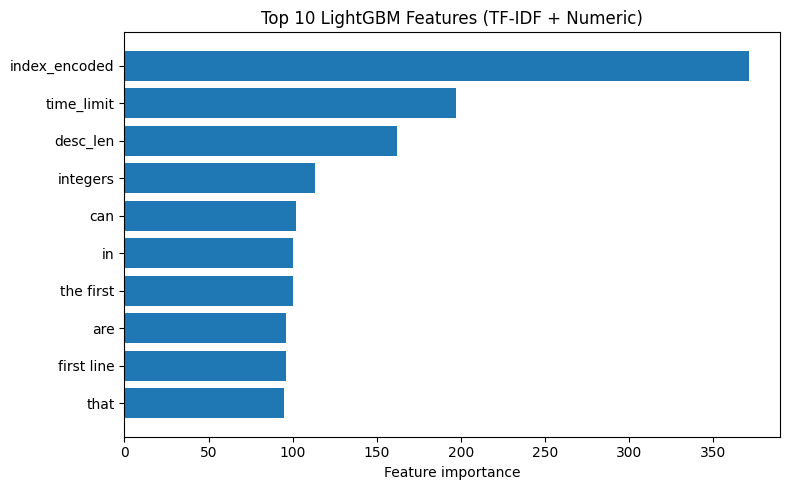

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(top10["feature"][::-1], top10["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Top 10 LightGBM Features (TF-IDF + Numeric)")
plt.tight_layout()
plt.show()


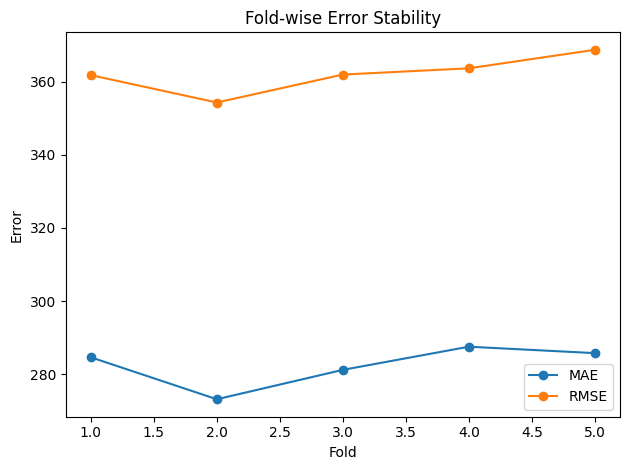

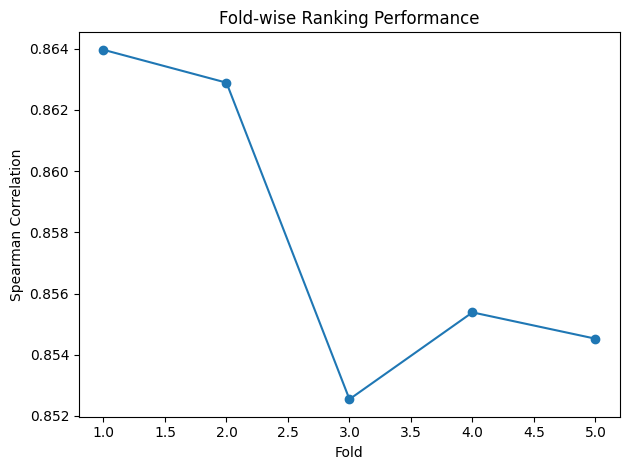

In [88]:
import matplotlib.pyplot as plt
import numpy as np

folds = range(1, 6)

plt.figure()
plt.plot(folds, results_lgbm_textnum["MAE"], marker="o", label="MAE")
plt.plot(folds, results_lgbm_textnum["RMSE"], marker="o", label="RMSE")
plt.xlabel("Fold")
plt.ylabel("Error")
plt.title("Fold-wise Error Stability")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(folds, results_lgbm_textnum["Spearman"], marker="o")
plt.xlabel("Fold")
plt.ylabel("Spearman Correlation")
plt.title("Fold-wise Ranking Performance")
plt.tight_layout()
plt.show()



# AFTER EMBEDDING

In [247]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Small, fast, very strong baseline
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded.")


Embedding model loaded.


In [248]:
# Make sure text exists
assert "all_text" in data.columns

texts = data["all_text"].fillna("").tolist()

# Encode text → dense vectors
text_embeddings = embedder.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings shape:", text_embeddings.shape)


Batches: 100%|██████████| 299/299 [03:51<00:00,  1.29it/s]

Embeddings shape: (9556, 384)


In [249]:
data = data.loc[:, ~data.columns.str.startswith("emb_")]


emb_cols = [f"emb_{i}" for i in range(text_embeddings.shape[1])]
emb_df = pd.DataFrame(text_embeddings, columns=emb_cols, index=data.index)

# Concatenate
data = pd.concat([data, emb_df], axis=1)

# Sanity checks
assert not data.columns.duplicated().any()
print("Data shape with embeddings:", data.shape)

Data shape with embeddings: (9556, 410)


In [250]:
# Numeric features (same as before)
numeric_features = [
    "index_encoded",
    "time_limit",
    "memory_limit",
    "contest_day_of_week",
    "contest_month",
    "desc_len",
    "title_len",
]

categorical_features = ["type_CF", "type_ICPC", "type_IOI"]

embedding_features = emb_cols

feature_cols_emb = embedding_features + numeric_features + categorical_features

target_col = "rating"

X_emb = data[feature_cols_emb]
X_emb = X_emb.loc[:, ~X_emb.columns.duplicated()]

y = data[target_col]

print("X_emb shape:", X_emb.shape)


X_emb shape: (9556, 394)


In [251]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

emb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# For LINEAR models (scaled)
X_emb_scaled = emb_pipeline.fit_transform(X_emb)

X_emb_scaled_df = pd.DataFrame(
    X_emb_scaled,
    columns=X_emb.columns,
    index=X_emb.index
)

# For TREE models (unscaled)
X_emb_df = pd.DataFrame(
    X_emb.values,
    columns=X_emb.columns,
    index=X_emb.index
)

print(
    "Scaled:", X_emb_scaled_df.shape,
    "Unscaled:", X_emb_df.shape,
    "Duplicates:", X_emb_df.columns.duplicated().any()
)



Scaled: (9556, 394) Unscaled: (9556, 394) Duplicates: False


In [252]:
ridge_emb = Ridge(alpha=1.0)

results_ridge_emb = run_kfold_model(
    ridge_emb,
    pd.DataFrame(X_emb_scaled),
    y,
    "Ridge_embeddings"
)

Fold 1 — MAE: 395.70, RMSE: 580.56, R²: 0.321, Spearman: 0.735
Fold 2 — MAE: 420.85, RMSE: 524.61, R²: 0.472, Spearman: 0.694
Fold 3 — MAE: 411.51, RMSE: 518.42, R²: 0.445, Spearman: 0.678
Fold 4 — MAE: 418.48, RMSE: 541.32, R²: 0.395, Spearman: 0.678
Fold 5 — MAE: 412.09, RMSE: 596.13, R²: 0.300, Spearman: 0.720

=== Ridge_embeddings ===
MAE: 411.73
RMSE: 552.21
R²: 0.386
Spearman: 0.701



In [ ]:
from sklearn.svm import LinearSVR

svr_emb = LinearSVR(C=1.0)

results_svr_emb = run_kfold_model(
    svr_emb,
    pd.DataFrame(X_emb_scaled),
    y,
    "LinearSVR_embeddings"
)


Fold 1 — MAE: 375.04, RMSE: 832.30, R²: -0.395, Spearman: 0.804
Fold 2 — MAE: 375.33, RMSE: 491.03, R²: 0.537, Spearman: 0.789
Fold 3 — MAE: 355.06, RMSE: 468.71, R²: 0.546, Spearman: 0.798
Fold 4 — MAE: 371.51, RMSE: 498.35, R²: 0.487, Spearman: 0.782
Fold 5 — MAE: 388.42, RMSE: 848.80, R²: -0.420, Spearman: 0.786

=== LinearSVR_embeddings ===
MAE: 373.07
RMSE: 627.84
R²: 0.151
Spearman: 0.792



In [254]:
# Force all columns to numeric (this is SAFE here)
X_emb_df = X_emb_df.apply(pd.to_numeric, errors="coerce")

# Optional: handle any NaNs created by coercion
X_emb_df = X_emb_df.fillna(0.0)

# Sanity check
print(X_emb_df.dtypes.value_counts())


float64    387
int64        4
bool         3
Name: count, dtype: int64


In [255]:
from lightgbm import LGBMRegressor

lgbm_emb = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

results_lgbm_emb = run_kfold_model(
    lgbm_emb,
    X_emb_df,     # <-- UNscaled embeddings
    y,
    "LightGBM_embeddings"
)


Fold 1 — MAE: 295.31, RMSE: 379.33, R²: 0.710, Spearman: 0.851
Fold 2 — MAE: 303.98, RMSE: 391.33, R²: 0.706, Spearman: 0.843
Fold 3 — MAE: 287.87, RMSE: 365.59, R²: 0.724, Spearman: 0.855
Fold 4 — MAE: 299.67, RMSE: 379.32, R²: 0.703, Spearman: 0.842
Fold 5 — MAE: 300.35, RMSE: 380.63, R²: 0.715, Spearman: 0.848

=== LightGBM_embeddings ===
MAE: 297.44
RMSE: 379.24
R²: 0.712
Spearman: 0.848



In [256]:
from xgboost import XGBRegressor

xgb_emb = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

results_xgb_emb = run_kfold_model(
    xgb_emb,
    X_emb_df,
    y,
    "XGBoost_embeddings"
)


Fold 1 — MAE: 295.42, RMSE: 377.72, R²: 0.713, Spearman: 0.852
Fold 2 — MAE: 304.10, RMSE: 390.47, R²: 0.707, Spearman: 0.845
Fold 3 — MAE: 289.71, RMSE: 366.68, R²: 0.722, Spearman: 0.853
Fold 4 — MAE: 301.07, RMSE: 383.78, R²: 0.696, Spearman: 0.839
Fold 5 — MAE: 301.21, RMSE: 381.48, R²: 0.713, Spearman: 0.848

=== XGBoost_embeddings ===
MAE: 298.30
RMSE: 380.03
R²: 0.710
Spearman: 0.847



In [259]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

X_train_emb = X_emb_df.loc[train_full.index]
y_train = train_full["rating"]

X_test_emb = X_emb_df.loc[test_final.index]
y_test = test_final["rating"]

print("Train emb:", X_train_emb.shape)
print("Test emb:", X_test_emb.shape)


lgbm_emb.fit(X_train_emb, y_train)

test_preds = lgbm_emb.predict(X_test_emb)

print("\n=== FINAL TEST — LightGBM (Embeddings + numeric) ===")
print("MAE:", mean_absolute_error(y_test, test_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))
print("R²:", r2_score(y_test, test_preds))
print("Spearman:", spearmanr(y_test, test_preds).correlation)



Train emb: (8234, 394)
Test emb: (1322, 394)

=== FINAL TEST — LightGBM (Embeddings + numeric) ===
MAE: 309.10439038801405
RMSE: 390.31592991123694
R²: 0.7504248256445852
Spearman: 0.8841942290606459
